# SuperStore Sales Analytics: Exploratory Data Analysis

In [ ]:
from pathlib import Path
from textwrap import fill
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import FancyBboxPatch
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

BG = "#f4efe6"       # Màu nền của toàn bộ figure
PANEL = "#fffdf8"    # Màu nền của từng biểu đồ (axes)
INK = "#1f2933"      # Màu chữ chính (title, label)
MUTED = "#64748b"    # Màu chữ phụ (tick, annotation nhẹ)
TEAL = "#0f8b8d"     # Màu xanh - thường dùng cho giá trị positive / profit
CORAL = "#e07a5f"    # Màu cam - thường dùng cho sales
GOLD = "#f2cc8f"     # Màu vàng nhạt
NAVY = "#3d405b"     # Màu xanh đậm
LOSS = "#b23a48"     # Màu đỏ - dùng cho giá trị âm / loss

# Gradient dùng cho Sales (giá trị thấp -> cao)
SALES_CMAP = LinearSegmentedColormap.from_list("sales_cmap", [GOLD, CORAL, NAVY])

# Gradient dùng cho Profit (lỗ -> hòa vốn -> lãi)
PROFIT_CMAP = LinearSegmentedColormap.from_list("profit_cmap", [LOSS, "#f8f5ef", TEAL])

# Global style cho toàn bộ matplotlib
# Các cấu hình này sẽ áp dụng cho mọi biểu đồ
plt.rcParams.update(
    {
        "figure.facecolor": BG,        # Màu nền của toàn bộ figure
        "axes.facecolor": PANEL,       # Màu nền của từng biểu đồ
        "savefig.facecolor": BG,       # Màu nền khi export hình
        "axes.edgecolor": "#d8d1c5",   # Màu viền của biểu đồ
        "axes.labelcolor": INK,        # Màu label trục
        "axes.titlecolor": INK,        # Màu tiêu đề
        "xtick.color": MUTED,          # Màu tick trục X
        "ytick.color": MUTED,          # Màu tick trục Y
        "text.color": INK,             # Màu chữ mặc định
        "axes.spines.top": False,      # Ẩn viền trên của biểu đồ
        "axes.spines.right": False,    # Ẩn viền bên phải
        "axes.grid": True,             # Bật grid cho biểu đồ
        "grid.color": "#e6dfd2",       # Màu grid
        "grid.linewidth": 0.8,         # Độ dày grid
        "grid.alpha": 0.85,            # Độ trong suốt của grid
        "font.family": "DejaVu Sans",  # Font mặc định
        "axes.titlepad": 14,           # Khoảng cách giữa title và chart
    }
)

# Thứ tự tháng trong năm (dùng cho biểu đồ theo thời gian)
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# Thứ tự các phương thức vận chuyển
# Sắp xếp theo tốc độ giao hàng (nhanh → chậm)
SHIP_MODE_ORDER = ["Same Day", "First Class", "Second Class", "Standard Class"]
# Nhãn các nhóm discount (dùng khi binning discount thành các khoảng)
# Ví dụ dùng cho histogram hoặc bar chart phân tích mức giảm giá
DISCOUNT_LABELS = ["0", "0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60%+"]

def currency_fmt(x, pos=None):
    """
    Format giá trị số thành chuỗi tiền tệ rút gọn để hiển thị trên biểu đồ.

    Quy ước:
    - >= 1,000,000  → hiển thị dạng M (Million)
    - >= 1,000      → hiển thị dạng K (Thousand)
    - < 1,000       → hiển thị bình thường
    
    Ví dụ:
    2500000 -> $2.5M
    12000   -> $12K
    500     -> $500
    """

    # Kiểm tra số âm để giữ lại dấu "-"
    sign = "-" if x < 0 else ""
    
    # Lấy giá trị tuyệt đối và chuyển sang float để đảm bảo tính toán
    x = abs(float(x))
    
    # Nếu >= 1 triệu → hiển thị đơn vị Million (M)
    if x >= 1_000_000:
        return f"{sign}${x / 1_000_000:.1f}M"
    
    # Nếu >= 1 nghìn → hiển thị đơn vị Thousand (K)
    if x >= 1_000:
        return f"{sign}${x / 1_000:.0f}K"
    
    # Nếu < 1 nghìn → hiển thị dạng tiền tệ bình thường
    # :,.0f → thêm dấu phẩy phân cách hàng nghìn, không có số thập phân
    return f"{sign}${x:,.0f}"

def pct_fmt(x):
    """
    Format số thành dạng phần trăm để hiển thị trên biểu đồ.

    Tham số
    -------
    x : float
        Giá trị số (thường nằm trong khoảng 0–1).

    Ví dụ
    -----
    0.25  -> 25%
    0.8   -> 80%
    1.0   -> 100%
    """

    # Format số thành phần trăm, làm tròn 0 chữ số thập phân
    # :.0% nghĩa là:
    #   - nhân giá trị với 100
    #   - thêm ký hiệu %
    #   - làm tròn đến số nguyên
    return f"{x:.0%}"


def wrap_for_axis(ax, text, base_chars=96, minimum=30):
    """
    Tự động xuống dòng (wrap text) cho chuỗi hiển thị trên biểu đồ
    dựa theo độ rộng thực tế của axes.

    Tham số
    -------
    ax : matplotlib.axes.Axes
        Đối tượng axes của biểu đồ.
    text : str
        Chuỗi cần format để hiển thị.
    base_chars : int, mặc định = 96
        Số ký tự tối đa khi axes có độ rộng chuẩn.
    minimum : int, mặc định = 30
        Số ký tự tối thiểu trước khi xuống dòng.

    Trả về
    -------
    str : Chuỗi đã được wrap để hiển thị đẹp hơn trên biểu đồ.
    """

    # Lấy độ rộng của axes (theo tỷ lệ trong figure)
    width = ax.get_position().width

    # Tính "ngân sách ký tự" dựa trên độ rộng của axes
    # axes càng rộng → hiển thị được nhiều ký tự hơn
    char_budget = max(minimum, int(base_chars * width))

    # Dùng textwrap.fill để tự động xuống dòng
    # break_long_words=False để tránh cắt ngang từ
    return fill(text, width=char_budget, break_long_words=False)


def style_axis(ax, title, subtitle=None, title_size=16.5, subtitle_size=10.5):
    """
    Thêm title và subtitle cho biểu đồ với style thống nhất.

    Hàm này:
    - Tự động wrap (xuống dòng) title/subtitle nếu quá dài
    - Điều chỉnh vị trí title dựa theo số dòng
    - Áp dụng style font và màu sắc đã định nghĩa

    Tham số
    -------
    ax : matplotlib.axes.Axes
        Đối tượng axes của biểu đồ.
    title : str
        Tiêu đề chính của biểu đồ.
    subtitle : str, optional
        Phụ đề mô tả thêm cho biểu đồ.
    title_size : float
        Kích thước font của title.
    subtitle_size : float
        Kích thước font của subtitle.
    """

    # Wrap title để tránh bị tràn nếu quá dài
    wrapped_title = wrap_for_axis(ax, title, base_chars=94, minimum=28)

    # Đếm số dòng của title sau khi wrap
    title_lines = wrapped_title.count("\n") + 1

    # Điều chỉnh vị trí Y của title dựa trên số dòng
    # Title càng nhiều dòng thì cần đẩy lên cao hơn
    title_y = 1.11 + 0.055 * (title_lines - 1)

    # Vẽ title lên chart
    ax.text(
        0,                      # vị trí X (bắt đầu từ mép trái)
        title_y,                # vị trí Y phía trên chart
        wrapped_title,          # nội dung title đã wrap
        transform=ax.transAxes, # dùng hệ tọa độ của axes
        ha="left",              # căn trái
        va="bottom",            # căn đáy
        fontsize=title_size,    # kích thước chữ
        fontweight="bold",      # chữ đậm
        color=INK,              # màu chữ chính
        clip_on=False,          # cho phép vẽ ra ngoài vùng axes
    )

    # Nếu có subtitle thì thêm phía dưới title
    if subtitle:
        # Wrap subtitle để xuống dòng nếu cần
        wrapped_subtitle = wrap_for_axis(ax, subtitle, base_chars=118, minimum=40)
        ax.text(
            0,
            title_y - 0.02,        # đặt subtitle ngay dưới title
            wrapped_subtitle,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=subtitle_size,
            color=MUTED,           # màu chữ nhẹ hơn
            clip_on=False,
        )


def finalize_figure(fig, top=0.88, bottom=0.09, left=0.08, right=0.97):
    """
    Điều chỉnh khoảng cách (margin) của toàn bộ figure.

    Hàm này dùng để tinh chỉnh layout của các subplot trong figure
    nhằm tránh việc title, label hoặc annotation bị cắt khi hiển thị
    hoặc khi export hình.

    Tham số
    -------
    fig : matplotlib.figure.Figure
        Đối tượng figure chứa các subplot.
    top : float
        Khoảng cách từ mép trên của figure.
    bottom : float
        Khoảng cách từ mép dưới của figure.
    left : float
        Khoảng cách từ mép trái của figure.
    right : float
        Khoảng cách từ mép phải của figure.
    """

    # Điều chỉnh layout của toàn bộ figure
    # giúp các subplot có khoảng cách hợp lý và không bị chồng lấn
    fig.subplots_adjust(
        top=top,
        bottom=bottom,
        left=left,
        right=right
    )

def draw_metric_card(ax, title, value, subtitle, accent):
    """
    Vẽ một "metric card" hiển thị KPI trên dashboard.

    Card bao gồm:
    - Tiêu đề KPI
    - Giá trị chính (value)
    - Mô tả ngắn (subtitle)
    - Màu accent để nhấn mạnh KPI

    Tham số
    -------
    ax : matplotlib.axes.Axes
        Axes dùng để vẽ card.
    title : str
        Tên KPI (ví dụ: Total Sales).
    value : str
        Giá trị KPI hiển thị lớn ở trung tâm.
    subtitle : str
        Mô tả bổ sung cho KPI.
    accent : str
        Màu nhấn (viền của card).
    """

    # Tắt toàn bộ trục (axis) vì card chỉ hiển thị text và shape
    ax.set_axis_off()

    # Tạo khung card bo góc
    card = FancyBboxPatch(
        (0, 0),                      # vị trí góc trái dưới
        1,                           # chiều rộng
        1,                           # chiều cao
        boxstyle="round,pad=0.02,rounding_size=0.04",  # bo góc card
        transform=ax.transAxes,      # dùng hệ tọa độ của axes
        linewidth=1.6,               # độ dày viền
        edgecolor=accent,            # màu viền (accent color)
        facecolor=PANEL,             # màu nền card
    )

    # Thêm card vào axes
    ax.add_patch(card)

    # Tiêu đề KPI (viết hoa)
    ax.text(
        0.06, 0.78,
        title.upper(),
        fontsize=10,
        fontweight="bold",
        color=MUTED,
        transform=ax.transAxes
    )

    # Giá trị KPI chính (hiển thị lớn)
    ax.text(
        0.06, 0.46,
        value,
        fontsize=24,
        fontweight="bold",
        color=INK,
        transform=ax.transAxes
    )

    # Mô tả bổ sung cho KPI
    ax.text(
        0.06, 0.18,
        subtitle,
        fontsize=11,
        color=MUTED,
        transform=ax.transAxes
    )

In [2]:
candidate_paths = [
    Path("/kaggle/input/datasets/thuandao/superstore-sales-analytics/SuperStoreOrders - SuperStoreOrders.csv"),
    Path("SuperStoreOrders - SuperStoreOrders.csv"),
    Path("../SuperStoreOrders - SuperStoreOrders.csv"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not locate 'SuperStoreOrders - SuperStoreOrders.csv' from the current working directory.")

df_raw = pd.read_csv(DATA_PATH)

df = df_raw.copy()
df["sales"] = pd.to_numeric(df["sales"].astype(str).str.replace(",", "", regex=False), errors="raise")
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], dayfirst=True)
df["ship_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit_margin"] = np.where(df["sales"] > 0, df["profit"] / df["sales"], np.nan)
df["shipping_intensity"] = np.where(df["sales"] > 0, df["shipping_cost"] / df["sales"], np.nan)
df["unit_price"] = np.where(df["quantity"] > 0, df["sales"] / df["quantity"], np.nan)
df["loss_flag"] = df["profit"] < 0
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()
df["month_name"] = pd.Categorical(df["order_date"].dt.strftime("%b"), categories=MONTH_ORDER, ordered=True)
df["discount_band"] = pd.cut(
    df["discount"],
    bins=[-0.001, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 1],
    labels=DISCOUNT_LABELS,
    ordered=True,
)
df["ship_mode"] = pd.Categorical(df["ship_mode"], categories=SHIP_MODE_ORDER, ordered=True)

assert df["sales"].isna().sum() == 0
assert df["order_date"].isna().sum() == 0
assert df["ship_date"].isna().sum() == 0
assert df["ship_days"].between(0, 7).all()

order_level = (
    df.groupby("order_id", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        quantity=("quantity", "sum"),
        line_items=("product_id", "size"),
    )
    .assign(margin=lambda d: d["profit"] / d["sales"])
)

monthly = (
    df.groupby("order_month", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
    )
    .sort_values("order_month")
)
monthly["margin"] = monthly["profit"] / monthly["sales"]
monthly["sales_roll3"] = monthly["sales"].rolling(3, min_periods=1).mean()
monthly["year"] = monthly["order_month"].dt.year
monthly["month_name"] = pd.Categorical(monthly["order_month"].dt.strftime("%b"), categories=MONTH_ORDER, ordered=True)

category_perf = (
    df.groupby("category", as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), quantity=("quantity", "sum"))
    .assign(margin=lambda d: d["profit"] / d["sales"])
    .sort_values("sales", ascending=False)
)

subcat_perf = (
    df.groupby(["category", "sub_category"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), quantity=("quantity", "sum"), orders=("order_id", "nunique"))
    .assign(margin=lambda d: d["profit"] / d["sales"])
)

market_perf = (
    df.groupby("market", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_name", "nunique"),
    )
    .assign(margin=lambda d: d["profit"] / d["sales"])
    .sort_values("sales", ascending=False)
)

region_share = (
    df.groupby(["region", "market"], as_index=False)["sales"]
    .sum()
    .pivot(index="region", columns="market", values="sales")
    .fillna(0)
)
region_share = region_share.loc[region_share.sum(axis=1).sort_values(ascending=False).index]
region_share = region_share.div(region_share.sum(axis=0), axis=1).fillna(0)

segment_perf = (
    df.groupby("segment", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_name", "nunique"),
    )
    .assign(margin=lambda d: d["profit"] / d["sales"])
    .sort_values("sales", ascending=False)
)

ship_mode_perf = (
    df.groupby("ship_mode", observed=False, as_index=False)
    .agg(
        avg_days=("ship_days", "mean"),
        median_days=("ship_days", "median"),
        q25=("ship_days", lambda s: s.quantile(0.25)),
        q75=("ship_days", lambda s: s.quantile(0.75)),
        avg_shipping_cost=("shipping_cost", "mean"),
        rows=("order_id", "size"),
    )
    .assign(order_share=lambda d: d["rows"] / d["rows"].sum())
)

priority_perf = (
    df.groupby("order_priority", as_index=False)
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_ship_days=("ship_days", "mean"),
        avg_shipping_cost=("shipping_cost", "mean"),
        rows=("order_id", "size"),
    )
    .assign(margin=lambda d: d["profit"] / d["sales"])
)

discount_band_perf = (
    df.groupby("discount_band", observed=False, as_index=False)
    .agg(rows=("order_id", "size"), sales=("sales", "sum"), profit=("profit", "sum"))
    .assign(margin=lambda d: d["profit"] / d["sales"])
)

discount_curve = (
    df.groupby("discount", as_index=False)
    .agg(median_margin=("profit_margin", "median"), rows=("order_id", "size"))
    .sort_values("discount")
)

category_discount_margin = (
    df.groupby(["category", "discount_band"], observed=False, as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"))
    .assign(margin=lambda d: d["profit"] / d["sales"])
    .pivot(index="category", columns="discount_band", values="margin")
    .reindex(columns=DISCOUNT_LABELS)
)

seasonal_margin = (
    monthly.pivot(index="year", columns="month_name", values="margin")
    .reindex(columns=MONTH_ORDER)
)

seasonal_sales = (
    monthly.pivot(index="year", columns="month_name", values="sales")
    .reindex(columns=MONTH_ORDER)
)

risk_pockets = (
    df.groupby(["market", "sub_category"], as_index=False)
    .agg(sales=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .assign(margin=lambda d: d["profit"] / d["sales"])
    .sort_values("profit")
)

country_market_conflicts = (
    df.groupby("country")["market"]
    .nunique()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

overall_sales = df["sales"].sum()
overall_profit = df["profit"].sum()
overall_margin = overall_profit / overall_sales

display(pd.DataFrame({"dataset_path": [str(DATA_PATH.resolve())]}))

,dataset_path
0,/kaggle/input/datasets/thuandao/superstore-sal...


## 1. Data audit

In [3]:
audit = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Raw columns",
            "Engineered features",
            "Unique orders",
            "Unique customers",
            "Unique products",
            "Countries",
            "Markets",
            "Date range",
            "Exact duplicate rows",
            "Duplicate (order_id, product_id, order_date) keys",
            "Zero-sales rows",
            "Loss-making rows",
        ],
        "Value": [
            f"{len(df):,}",
            f"{df_raw.shape[1]:,}",
            f"{df.shape[1] - df_raw.shape[1]:,}",
            f"{df['order_id'].nunique():,}",
            f"{df['customer_name'].nunique():,}",
            f"{df['product_id'].nunique():,}",
            f"{df['country'].nunique():,}",
            f"{df['market'].nunique():,}",
            f"{df['order_date'].min().date()} to {df['order_date'].max().date()}",
            f"{df.duplicated().sum():,}",
            f"{df.duplicated(subset=['order_id', 'product_id', 'order_date']).sum():,}",
            f"{(df['sales'] == 0).sum():,}",
            f"{df['loss_flag'].mean():.1%}",
        ],
    }
)

numeric_summary = (
    df[["sales", "profit", "discount", "quantity", "shipping_cost", "ship_days"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
    .round(3)
)

display(audit)
display(numeric_summary)

if not country_market_conflicts.empty:
    display(
        pd.DataFrame(
            {
                "country": country_market_conflicts.index,
                "distinct_markets": country_market_conflicts.values,
            }
        )
    )

,Metric,Value
0,Rows,"51,290"
1,Raw columns,21
2,Engineered features,8
3,Unique orders,"25,035"
4,Unique customers,795
5,Unique products,"10,292"
6,Countries,147
7,Markets,7
8,Date range,2011-01-01 to 2014-12-31
9,Exact duplicate rows,0


,count,mean,std,min,1%,5%,50%,95%,99%,max
sales,51290.0,246.498,487.567,0.000,4.000,9.000,85.00,1016.000,2301.000,22638.000
profit,51290.0,28.642,174.424,-6599.978,-351.506,-83.878,9.24,211.500,588.786,8399.976
discount,51290.0,0.143,0.212,0.000,0.000,0.000,0.00,0.600,0.700,0.850
quantity,51290.0,3.477,2.279,1.000,1.000,1.000,3.00,8.000,11.000,14.000
shipping_cost,51290.0,26.376,57.297,0.000,0.200,0.610,7.79,111.409,286.754,933.570
ship_days,51290.0,3.969,1.729,0.000,0.000,0.000,4.00,7.000,7.000,7.000


,country,distinct_markets
0,Austria,2
1,Mongolia,2


## 2. Data snapshot

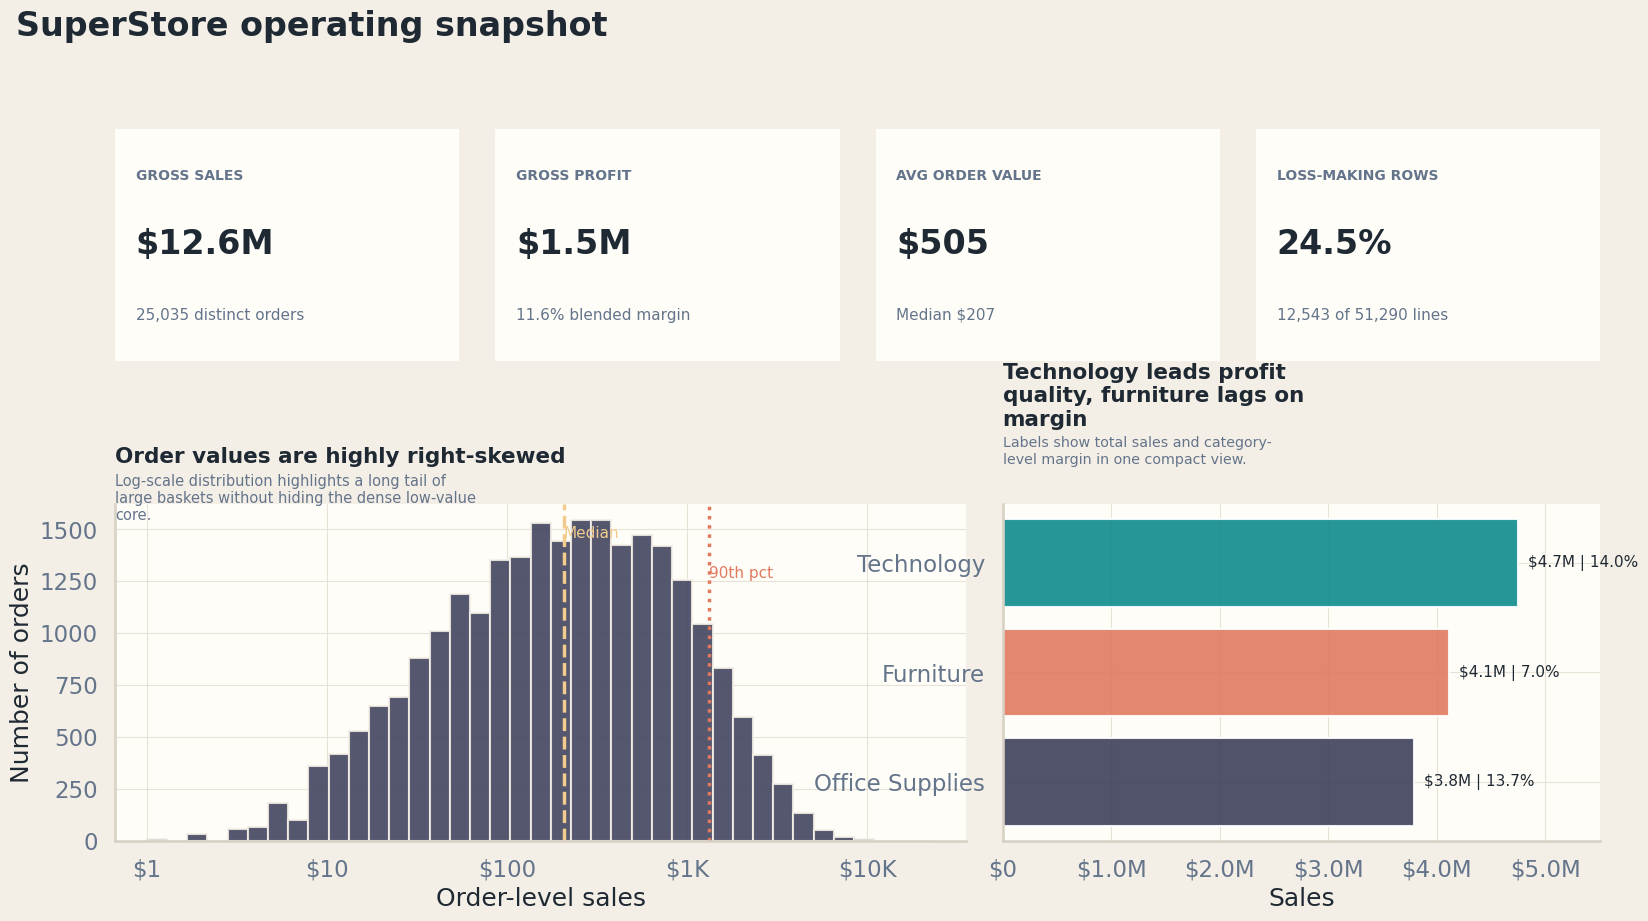

In [4]:
fig = plt.figure(figsize=(16.5, 9.5))
gs = fig.add_gridspec(2, 12, height_ratios=[1, 1.45], hspace=0.5, wspace=0.4)

metrics = [
    ("Gross sales", currency_fmt(overall_sales), f"{df['order_id'].nunique():,} distinct orders", NAVY),
    ("Gross profit", currency_fmt(overall_profit), f"{overall_margin:.1%} blended margin", TEAL),
    ("Avg order value", currency_fmt(order_level['sales'].mean()), f"Median {currency_fmt(order_level['sales'].median())}", CORAL),
    ("Loss-making rows", f"{df['loss_flag'].mean():.1%}", f"{(df['profit'] < 0).sum():,} of {len(df):,} lines", LOSS),
]

for i, metric in enumerate(metrics):
    ax = fig.add_subplot(gs[0, i * 3:(i + 1) * 3])
    draw_metric_card(ax, *metric)

ax_dist = fig.add_subplot(gs[1, :7])
positive_orders = order_level.loc[order_level["sales"] > 0, "sales"]
bins = np.geomspace(max(1, positive_orders.min()), positive_orders.max(), 40)
ax_dist.hist(positive_orders, bins=bins, color=NAVY, alpha=0.88, edgecolor=BG)
ax_dist.set_xscale("log")
ax_dist.axvline(order_level["sales"].median(), color=GOLD, linewidth=2.5, linestyle="--")
ax_dist.axvline(order_level["sales"].quantile(0.9), color=CORAL, linewidth=2.5, linestyle=":")
ax_dist.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_dist,
    "Order values are highly right-skewed",
    "Log-scale distribution highlights a long tail of large baskets without hiding the dense low-value core.",
    title_size=15.5,
    subtitle_size=10.5,
)
ax_dist.set_xlabel("Order-level sales")
ax_dist.set_ylabel("Number of orders")
ax_dist.margins(x=0.04)
ax_dist.text(order_level["sales"].median(), ax_dist.get_ylim()[1] * 0.9, "Median", color=GOLD, fontsize=11)
ax_dist.text(order_level["sales"].quantile(0.9), ax_dist.get_ylim()[1] * 0.78, "90th pct", color=CORAL, fontsize=11)

ax_cat = fig.add_subplot(gs[1, 7:])
category_plot = category_perf.sort_values("sales", ascending=True)
bar_colors = [NAVY, CORAL, TEAL]
ax_cat.barh(category_plot["category"], category_plot["sales"], color=bar_colors, alpha=0.9)
ax_cat.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_cat,
    "Technology leads profit quality, furniture lags on margin",
    "Labels show total sales and category-level margin in one compact view.",
    title_size=15.5,
    subtitle_size=10.3,
)
ax_cat.set_xlabel("Sales")
ax_cat.set_ylabel("")
ax_cat.margins(x=0.16)
x_pad = category_plot["sales"].max() * 0.02
for y, row in enumerate(category_plot.itertuples(index=False)):
    ax_cat.text(
        row.sales + x_pad,
        y,
        f"{currency_fmt(row.sales)} | {row.margin:.1%}",
        va="center",
        fontsize=11,
        color=INK,
    )

finalize_figure(fig, top=0.86, bottom=0.11, left=0.07, right=0.97)
fig.suptitle("SuperStore operating snapshot", x=0.01, y=0.985, ha="left", fontsize=24, fontweight="bold")
plt.show()

## 3. Time structure

Retail datasets often look healthier in aggregate than they do through time. The next view separates trend from seasonality by combining a monthly run chart with a year-by-month margin heatmap.

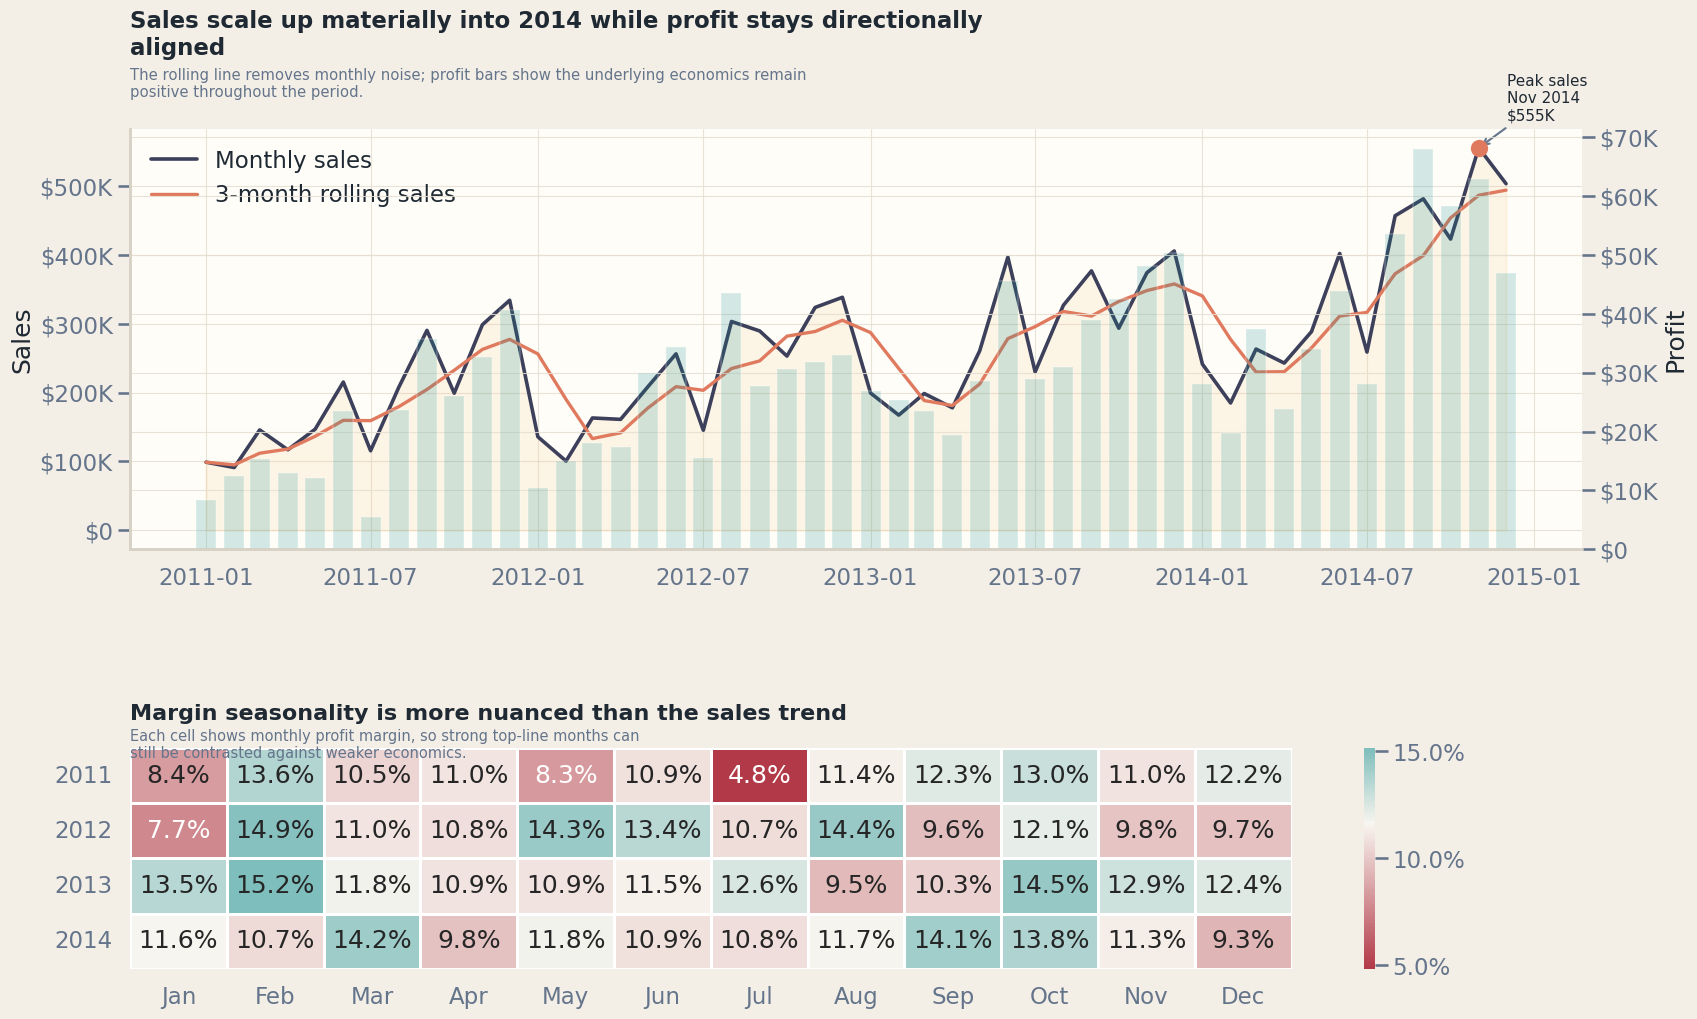

In [5]:
fig = plt.figure(figsize=(16.5, 10.5))
gs = fig.add_gridspec(2, 1, height_ratios=[2.1, 1.1], hspace=0.62)

ax_trend = fig.add_subplot(gs[0, 0])
ax_profit = ax_trend.twinx()

ax_trend.fill_between(monthly["order_month"], monthly["sales"], color=GOLD, alpha=0.18)
ax_trend.plot(monthly["order_month"], monthly["sales"], color=NAVY, linewidth=2.6, label="Monthly sales")
ax_trend.plot(monthly["order_month"], monthly["sales_roll3"], color=CORAL, linewidth=2.4, label="3-month rolling sales")
ax_profit.bar(monthly["order_month"], monthly["profit"], width=22, color=TEAL, alpha=0.18, label="Monthly profit")

peak_row = monthly.loc[monthly["sales"].idxmax()]
ax_trend.scatter(peak_row["order_month"], peak_row["sales"], s=120, color=CORAL, zorder=5)
ax_trend.annotate(
    f"Peak sales\n{peak_row['order_month']:%b %Y}\n{currency_fmt(peak_row['sales'])}",
    xy=(peak_row["order_month"], peak_row["sales"]),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": MUTED},
    fontsize=11,
    color=INK,
)

style_axis(
    ax_trend,
    "Sales scale up materially into 2014 while profit stays directionally aligned",
    "The rolling line removes monthly noise; profit bars show the underlying economics remain positive throughout the period.",
    title_size=16.5,
    subtitle_size=10.7,
)
ax_trend.set_ylabel("Sales")
ax_trend.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_profit.set_ylabel("Profit")
ax_profit.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_trend.legend(loc="upper left", frameon=False)

ax_heat = fig.add_subplot(gs[1, 0])
sns.heatmap(
    seasonal_margin,
    ax=ax_heat,
    cmap=PROFIT_CMAP,
    center=overall_margin,
    annot=True,
    fmt=".1%",
    linewidths=1,
    cbar_kws={"format": mtick.PercentFormatter(xmax=1)},
)
style_axis(
    ax_heat,
    "Margin seasonality is more nuanced than the sales trend",
    "Each cell shows monthly profit margin, so strong top-line months can still be contrasted against weaker economics.",
    title_size=16,
    subtitle_size=10.5,
)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")

finalize_figure(fig, top=0.92, bottom=0.12, left=0.08, right=0.96)
plt.show()

## 4. Geographic structure

Market totals alone are not enough. A strong market can still be regionally concentrated, and a weak market can sometimes be structurally clean but too small. This section pairs market scale with margin quality, then decomposes each market into its internal regional mix.

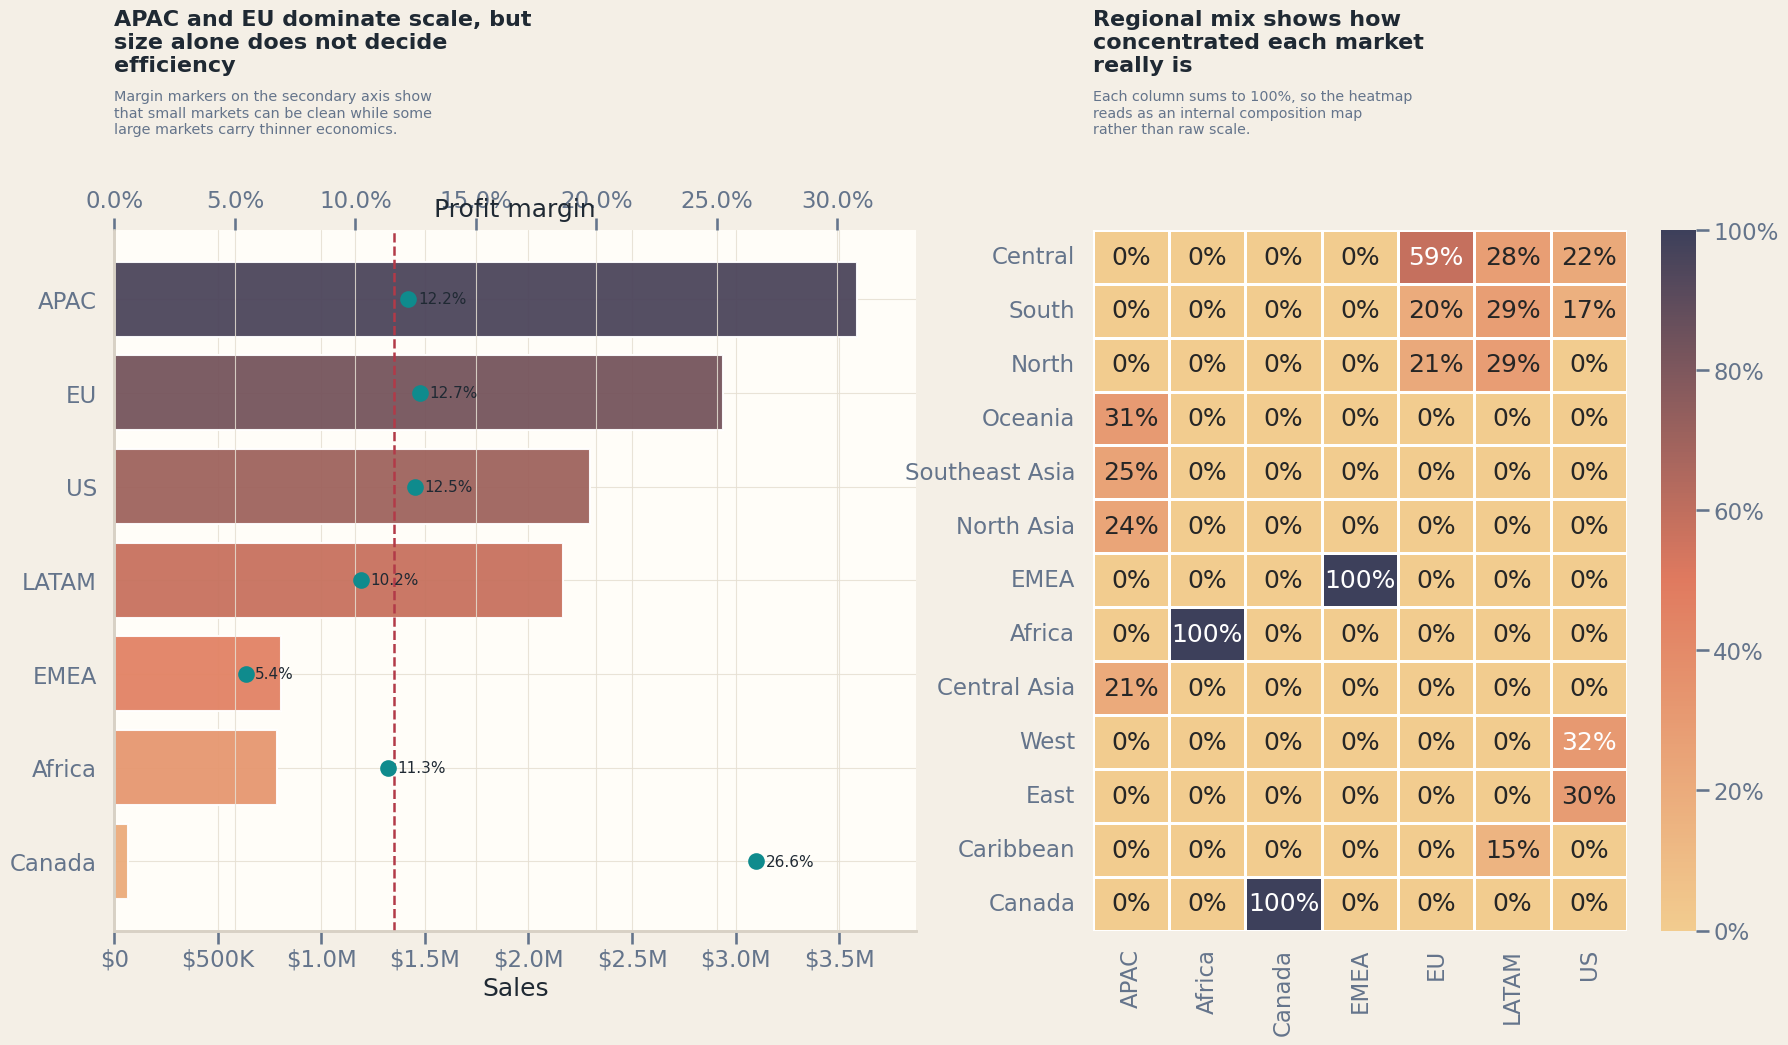

In [6]:
fig = plt.figure(figsize=(18.5, 9.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1], wspace=0.24)

ax_market = fig.add_subplot(gs[0, 0])
market_plot = market_perf.sort_values("sales", ascending=True).reset_index(drop=True)
y = np.arange(len(market_plot))
ax_market.barh(
    y,
    market_plot["sales"],
    color=[SALES_CMAP(i) for i in np.linspace(0.2, 0.95, len(market_plot))],
    alpha=0.95,
)
ax_market.set_yticks(y, market_plot["market"])
ax_market.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_market.set_xlabel("Sales")
style_axis(
    ax_market,
    "APAC and EU dominate scale, but size alone does not decide efficiency",
    "Margin markers on the secondary axis show that small markets can be clean while some large markets carry thinner economics.",
    title_size=16,
    subtitle_size=10.4,
)

ax_margin = ax_market.twiny()
ax_margin.scatter(market_plot["margin"], y, color=TEAL, s=110, zorder=5)
ax_margin.axvline(overall_margin, color=LOSS, linestyle="--", linewidth=1.8)
ax_margin.set_xlim(0, market_plot["margin"].max() * 1.25)
ax_margin.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax_margin.set_xlabel("Profit margin", labelpad=8)
ax_margin.xaxis.set_label_coords(0.5, 1.02)
ax_market.margins(x=0.08)
for idx, row in market_plot.iterrows():
    ax_margin.text(row["margin"] + 0.004, idx, f"{row['margin']:.1%}", va="center", fontsize=11, color=INK)

ax_heat = fig.add_subplot(gs[0, 1])
sns.heatmap(
    region_share,
    ax=ax_heat,
    cmap=SALES_CMAP,
    annot=True,
    fmt=".0%",
    linewidths=1,
    cbar_kws={"format": mtick.PercentFormatter(xmax=1)},
)
style_axis(
    ax_heat,
    "Regional mix shows how concentrated each market really is",
    "Each column sums to 100%, so the heatmap reads as an internal composition map rather than raw scale.",
    title_size=16,
    subtitle_size=10.3,
)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")

finalize_figure(fig, top=0.85, bottom=0.12, left=0.07, right=0.96)
plt.show()

## 5. Product portfolio anatomy

Product analysis should separate *scale* from *economic quality*. A sub-category with large revenue but poor profit is more dangerous than a small underperformer. The bubble map below encodes both forces at once.

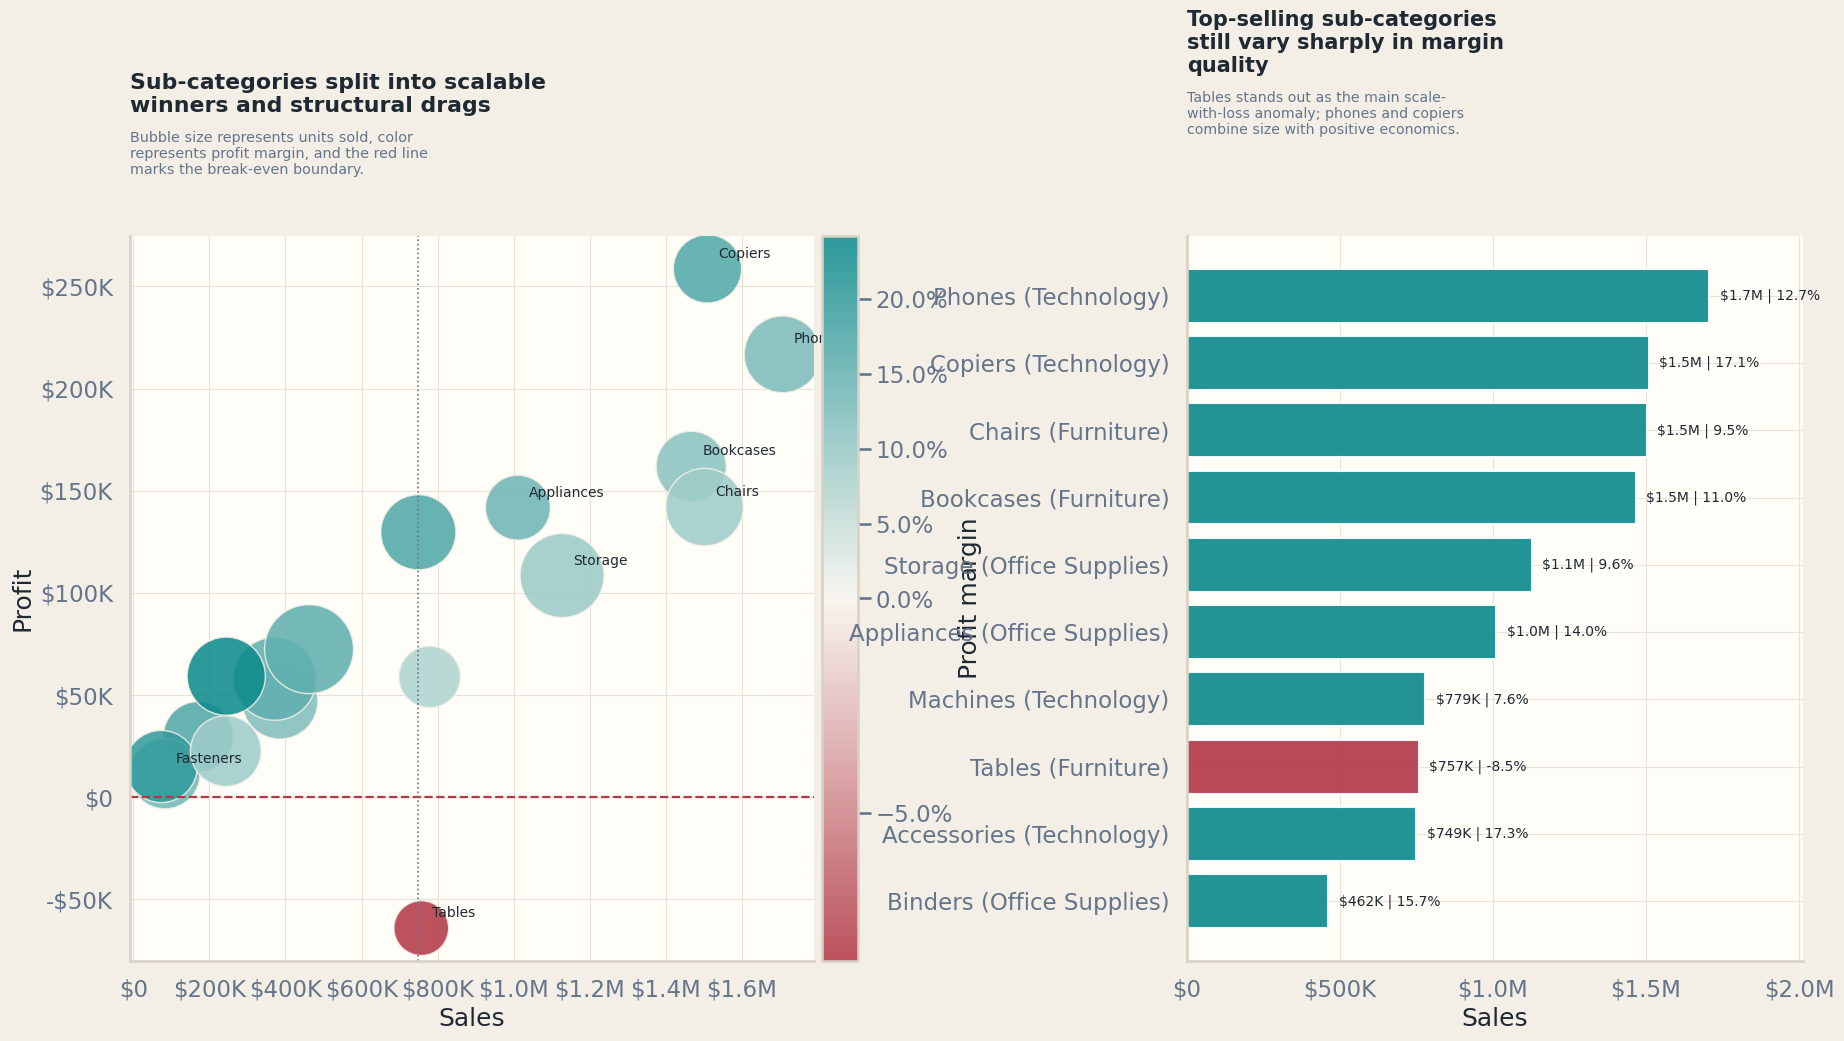

In [7]:
fig = plt.figure(figsize=(18.8, 9.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.32, 1], wspace=0.34)

ax_bubble = fig.add_subplot(gs[0, 0])
subcat_plot = subcat_perf.copy()
norm = TwoSlopeNorm(vmin=subcat_plot["margin"].min(), vcenter=0, vmax=subcat_plot["margin"].max())
bubble = ax_bubble.scatter(
    subcat_plot["sales"],
    subcat_plot["profit"],
    s=np.sqrt(subcat_plot["quantity"]) * 28,
    c=subcat_plot["margin"],
    cmap=PROFIT_CMAP,
    norm=norm,
    alpha=0.88,
    edgecolor=BG,
    linewidth=1,
)
ax_bubble.axhline(0, color=LOSS, linewidth=1.6, linestyle="--")
ax_bubble.axvline(subcat_plot["sales"].median(), color=MUTED, linewidth=1.2, linestyle=":")
ax_bubble.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
ax_bubble.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_bubble,
    "Sub-categories split into scalable winners and structural drags",
    "Bubble size represents units sold, color represents profit margin, and the red line marks the break-even boundary.",
    title_size=15.8,
    subtitle_size=10.4,
)
ax_bubble.set_xlabel("Sales")
ax_bubble.set_ylabel("Profit")

highlight = pd.concat(
    [
        subcat_plot.nlargest(6, "sales"),
        subcat_plot.nsmallest(2, "profit"),
    ]
).drop_duplicates(subset=["sub_category"])

for row in highlight.itertuples(index=False):
    ax_bubble.annotate(
        row.sub_category,
        xy=(row.sales, row.profit),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        color=INK,
    )

cbar = plt.colorbar(bubble, ax=ax_bubble, pad=0.01)
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
cbar.set_label("Profit margin")

ax_bar = fig.add_subplot(gs[0, 1])
top_sales = subcat_plot.nlargest(10, "sales").sort_values("sales", ascending=True)
bar_colors = [TEAL if profit >= 0 else LOSS for profit in top_sales["profit"]]
ax_bar.barh(
    top_sales["sub_category"] + " (" + top_sales["category"] + ")",
    top_sales["sales"],
    color=bar_colors,
    alpha=0.92,
)
ax_bar.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_bar,
    "Top-selling sub-categories still vary sharply in margin quality",
    "Tables stands out as the main scale-with-loss anomaly; phones and copiers combine size with positive economics.",
    title_size=15,
    subtitle_size=10.2,
)
ax_bar.set_xlabel("Sales")
ax_bar.set_ylabel("")
ax_bar.margins(x=0.18)
pad = top_sales["sales"].max() * 0.02
for y, row in enumerate(top_sales.itertuples(index=False)):
    ax_bar.text(
        row.sales + pad,
        y,
        f"{currency_fmt(row.sales)} | {row.margin:.1%}",
        va="center",
        fontsize=10,
        color=INK,
    )

finalize_figure(fig, top=0.86, bottom=0.12, left=0.07, right=0.96)
plt.show()

## 6. Discount mechanics and margin erosion

A retail dataset usually becomes strategically useful when discounting is treated as a causal business lever rather than a descriptive column. The goal here is to locate the point where price concessions stop stimulating profitable revenue and start manufacturing losses.

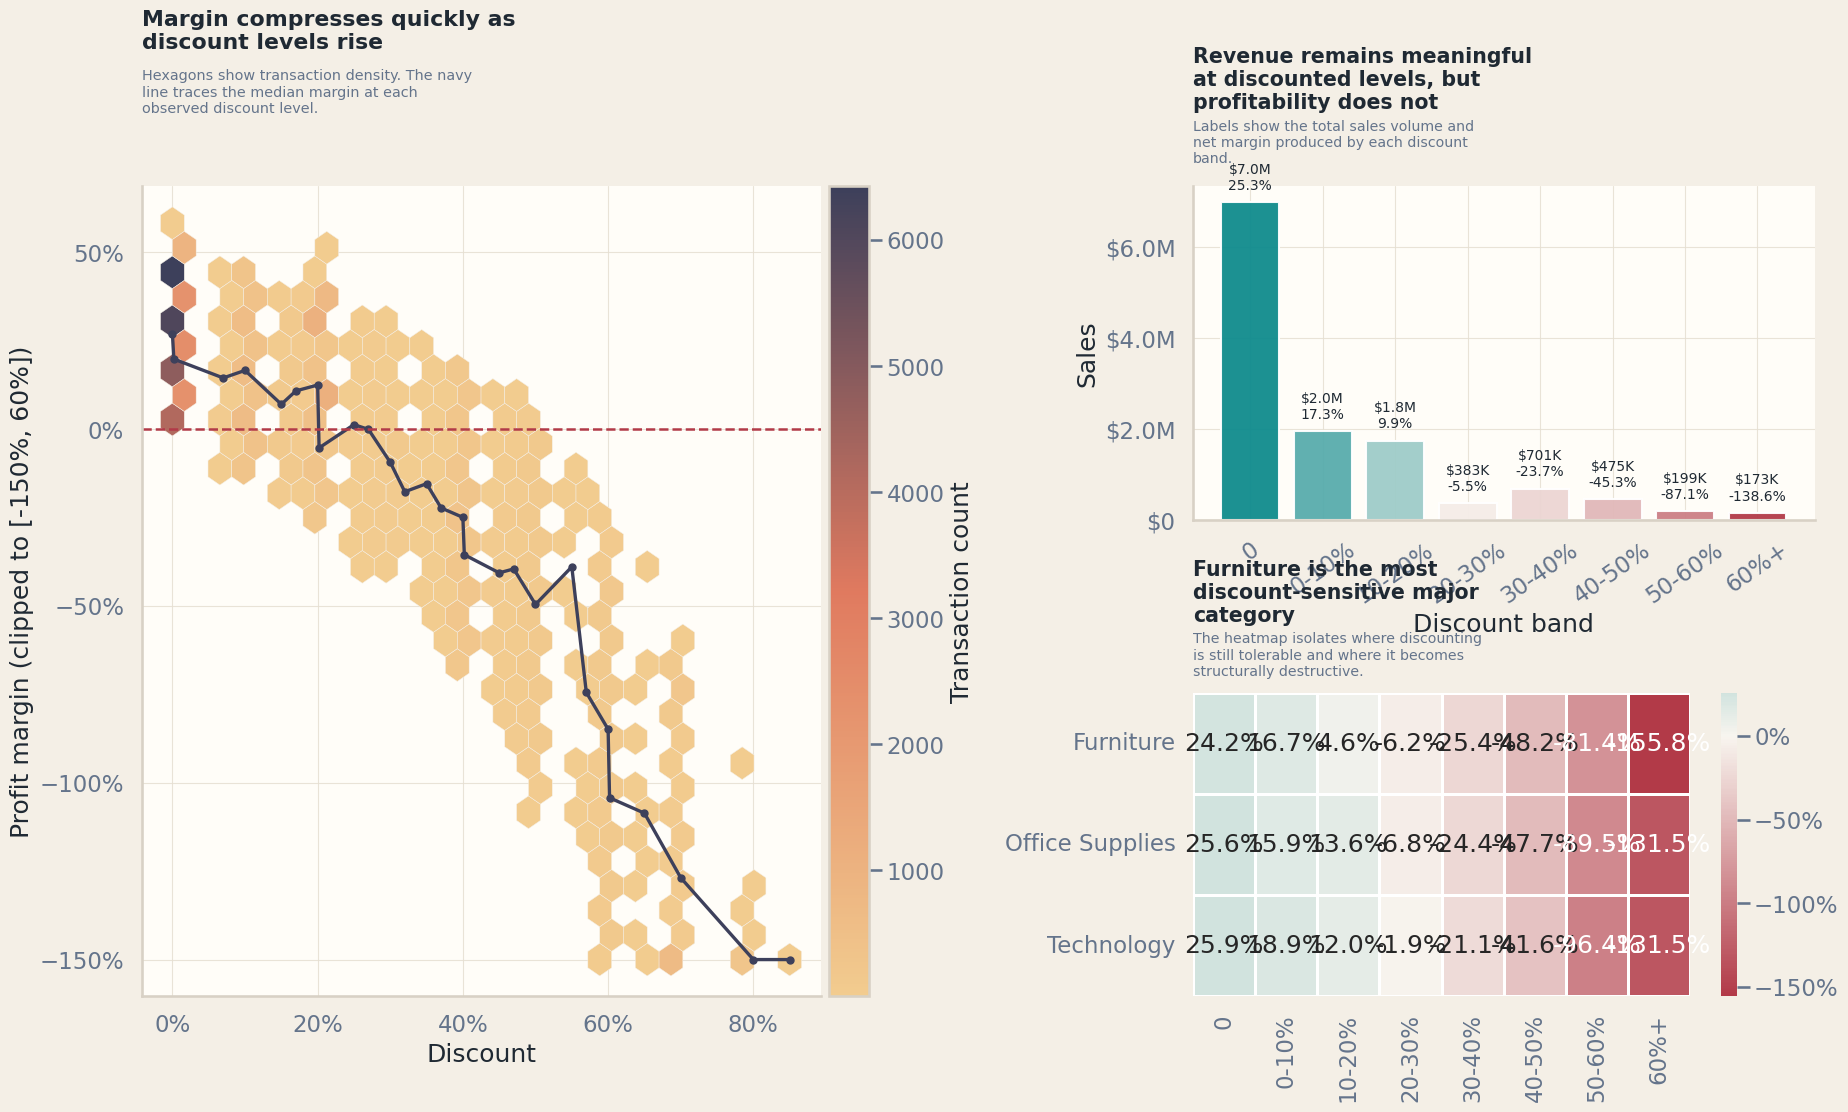

In [8]:
fig = plt.figure(figsize=(18.8, 10.8))
gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1], height_ratios=[1.1, 1], wspace=0.34, hspace=0.54)

ax_hex = fig.add_subplot(gs[:, 0])
margin_clip = df["profit_margin"].clip(-1.5, 0.6)
hb = ax_hex.hexbin(
    df["discount"],
    margin_clip,
    gridsize=26,
    mincnt=1,
    cmap=SALES_CMAP,
    linewidths=0.35,
    edgecolors=BG,
)
ax_hex.plot(
    discount_curve["discount"],
    discount_curve["median_margin"].clip(-1.5, 0.6),
    color=NAVY,
    linewidth=2.4,
    marker="o",
    markersize=5,
)
ax_hex.axhline(0, color=LOSS, linestyle="--", linewidth=1.8)
style_axis(
    ax_hex,
    "Margin compresses quickly as discount levels rise",
    "Hexagons show transaction density. The navy line traces the median margin at each observed discount level.",
    title_size=15.8,
    subtitle_size=10.4,
)
ax_hex.set_xlabel("Discount")
ax_hex.set_ylabel("Profit margin (clipped to [-150%, 60%])")
ax_hex.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax_hex.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
cbar = plt.colorbar(hb, ax=ax_hex, pad=0.01)
cbar.set_label("Transaction count")

ax_band = fig.add_subplot(gs[0, 1])
band_plot = discount_band_perf.copy()
band_norm = TwoSlopeNorm(vmin=band_plot["margin"].min(), vcenter=0, vmax=band_plot["margin"].max())
band_colors = [PROFIT_CMAP(band_norm(value)) for value in band_plot["margin"]]
ax_band.bar(band_plot["discount_band"].astype(str), band_plot["sales"], color=band_colors, alpha=0.95)
ax_band.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_band,
    "Revenue remains meaningful at discounted levels, but profitability does not",
    "Labels show the total sales volume and net margin produced by each discount band.",
    title_size=14.8,
    subtitle_size=10.2,
)
ax_band.set_xlabel("Discount band")
ax_band.set_ylabel("Sales")
ax_band.tick_params(axis="x", rotation=35)
y_pad = band_plot["sales"].max() * 0.03
for x, row in enumerate(band_plot.itertuples(index=False)):
    ax_band.text(
        x,
        row.sales + y_pad,
        f"{currency_fmt(row.sales)}\n{row.margin:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=INK,
    )

ax_heat = fig.add_subplot(gs[1, 1])
sns.heatmap(
    category_discount_margin,
    ax=ax_heat,
    cmap=PROFIT_CMAP,
    center=0,
    annot=True,
    fmt=".1%",
    linewidths=1,
    cbar_kws={"format": mtick.PercentFormatter(xmax=1)},
)
style_axis(
    ax_heat,
    "Furniture is the most discount-sensitive major category",
    "The heatmap isolates where discounting is still tolerable and where it becomes structurally destructive.",
    title_size=14.8,
    subtitle_size=10.2,
)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")

finalize_figure(fig, top=0.88, bottom=0.13, left=0.07, right=0.96)
plt.show()

## 7. Customer and fulfillment operating model

Revenue quality is not only a pricing story. The mix of customer segments, ship modes, and order priorities affects service levels and shipping cost intensity, which in turn influence margin resilience.

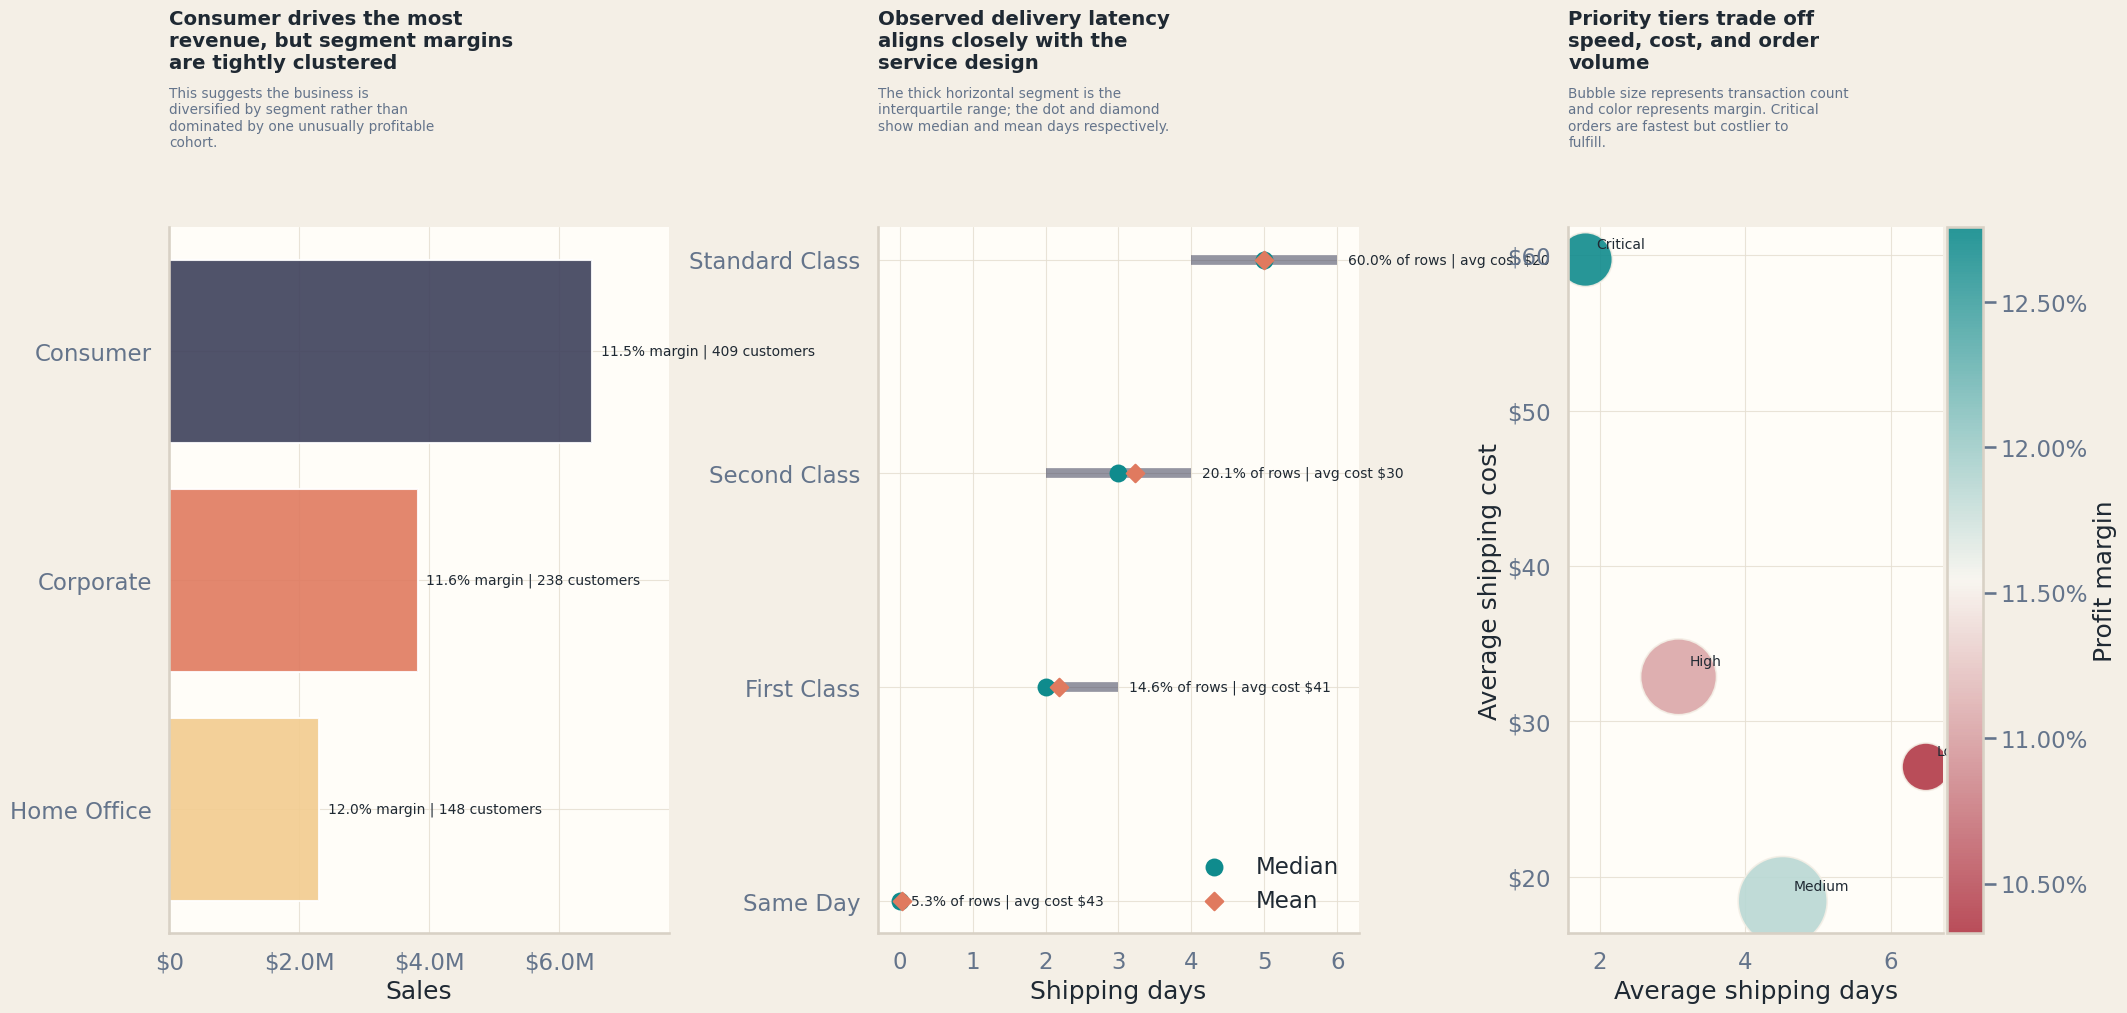

In [9]:
fig = plt.figure(figsize=(20.5, 9.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.12, 1.08, 1], wspace=0.44)

ax_segment = fig.add_subplot(gs[0, 0])
seg_plot = segment_perf.sort_values("sales", ascending=True)
ax_segment.barh(seg_plot["segment"], seg_plot["sales"], color=[GOLD, CORAL, NAVY], alpha=0.9)
ax_segment.xaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
style_axis(
    ax_segment,
    "Consumer drives the most revenue, but segment margins are tightly clustered",
    "This suggests the business is diversified by segment rather than dominated by one unusually profitable cohort.",
    title_size=14.2,
    subtitle_size=9.8,
)
ax_segment.set_xlabel("Sales")
ax_segment.set_ylabel("")
ax_segment.margins(x=0.18)
seg_pad = seg_plot["sales"].max() * 0.02
for y, row in enumerate(seg_plot.itertuples(index=False)):
    ax_segment.text(
        row.sales + seg_pad,
        y,
        f"{row.margin:.1%} margin | {row.customers} customers",
        va="center",
        fontsize=10,
        color=INK,
    )

ax_ship = fig.add_subplot(gs[0, 1])
ship_plot = ship_mode_perf.copy().sort_values("avg_days", ascending=True).reset_index(drop=True)
y = np.arange(len(ship_plot))
ax_ship.hlines(y, ship_plot["q25"], ship_plot["q75"], color=NAVY, linewidth=7, alpha=0.55)
ax_ship.scatter(ship_plot["median_days"], y, color=TEAL, s=130, zorder=3, label="Median")
ax_ship.scatter(ship_plot["avg_days"], y, color=CORAL, s=80, marker="D", zorder=3, label="Mean")
ax_ship.set_yticks(y, ship_plot["ship_mode"].astype(str))
ax_ship.set_xlabel("Shipping days")
ax_ship.set_ylabel("")
style_axis(
    ax_ship,
    "Observed delivery latency aligns closely with the service design",
    "The thick horizontal segment is the interquartile range; the dot and diamond show median and mean days respectively.",
    title_size=14.2,
    subtitle_size=9.8,
)
ax_ship.legend(frameon=False, loc="lower right")
for idx, row in ship_plot.iterrows():
    ax_ship.text(
        row["q75"] + 0.15,
        idx,
        f"{row['order_share']:.1%} of rows | avg cost {currency_fmt(row['avg_shipping_cost'])}",
        va="center",
        fontsize=10,
        color=INK,
    )

ax_priority = fig.add_subplot(gs[0, 2])
bubble = ax_priority.scatter(
    priority_perf["avg_ship_days"],
    priority_perf["avg_shipping_cost"],
    s=np.sqrt(priority_perf["rows"]) * 24,
    c=priority_perf["margin"],
    cmap=PROFIT_CMAP,
    alpha=0.9,
    edgecolor=BG,
    linewidth=1.2,
)
style_axis(
    ax_priority,
    "Priority tiers trade off speed, cost, and order volume",
    "Bubble size represents transaction count and color represents margin. Critical orders are fastest but costlier to fulfill.",
    title_size=14.2,
    subtitle_size=9.8,
)
ax_priority.set_xlabel("Average shipping days")
ax_priority.set_ylabel("Average shipping cost")
ax_priority.yaxis.set_major_formatter(mtick.FuncFormatter(currency_fmt))
for row in priority_perf.itertuples(index=False):
    ax_priority.annotate(
        row.order_priority,
        xy=(row.avg_ship_days, row.avg_shipping_cost),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        color=INK,
    )
cbar = plt.colorbar(bubble, ax=ax_priority, pad=0.01)
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
cbar.set_label("Profit margin")

finalize_figure(fig, top=0.84, bottom=0.12, left=0.06, right=0.96)
plt.show()

## 8. Risk pockets and first conclusions

In [10]:
top_loss_pockets = risk_pockets.head(12).copy()
top_profit_pockets = risk_pockets.tail(12).sort_values("profit", ascending=False).copy()

display(top_loss_pockets.round({"sales": 0, "profit": 0, "margin": 4}))
display(top_profit_pockets.round({"sales": 0, "profit": 0, "margin": 4}))

top_market = market_perf.iloc[0]
cleanest_market = market_perf.loc[market_perf["margin"].idxmax()]
worst_subcategory = subcat_perf.loc[subcat_perf["profit"].idxmin()]
best_subcategory = subcat_perf.loc[subcat_perf["profit"].idxmax()]
fastest_mode = ship_mode_perf.loc[ship_mode_perf["avg_days"].idxmin()]

takeaways = [
    f"{top_market['market']} is the largest market by sales at {currency_fmt(top_market['sales'])}, with a healthy but not category-leading margin of {top_market['margin']:.1%}.",
    f"{cleanest_market['market']} has the strongest market-level margin at {cleanest_market['margin']:.1%}, although it contributes much less absolute volume.",
    f"{worst_subcategory['sub_category']} is the main structural loss pocket: {currency_fmt(worst_subcategory['sales'])} of sales but {currency_fmt(worst_subcategory['profit'])} of profit.",
    f"{best_subcategory['sub_category']} is the strongest absolute profit contributor at {currency_fmt(best_subcategory['profit'])}.",
    f"Margins turn negative from the 20-30% discount band onward and deteriorate sharply beyond 40%, which makes discount governance a priority lever.",
    f"{fastest_mode['ship_mode']} is the fastest observed ship mode at {fastest_mode['avg_days']:.2f} days on average.",
]

for takeaway in takeaways:
    print(f"- {takeaway}")

,market,sub_category,sales,profit,orders,margin
84,EU,Tables,105380,-20998.0,91,-0.1993
16,APAC,Tables,225096,-20129.0,181,-0.0894
118,US,Tables,206968,-17725.0,307,-0.0856
101,LATAM,Tables,144878,-12306.0,173,-0.0849
106,US,Bookcases,114879,-3473.0,224,-0.0302
117,US,Supplies,46679,-1189.0,187,-0.0255
56,EMEA,Chairs,69821,-610.0,236,-0.0087
43,Canada,Furnishings,809,114.0,15,0.1407
44,Canada,Labels,423,129.0,23,0.3057
42,Canada,Fasteners,478,140.0,18,0.2932


,market,sub_category,sales,profit,orders,margin
13,APAC,Phones,486350,81314.0,646,0.1672
6,APAC,Copiers,494593,80854.0,623,0.1635
4,APAC,Bookcases,504826,67657.0,587,0.1340
5,APAC,Chairs,512981,63780.0,893,0.1243
72,EU,Bookcases,363519,56407.0,453,0.1552
74,EU,Copiers,365139,56200.0,444,0.1539
108,US,Copiers,149530,55618.0,68,0.3720
69,EU,Appliances,275442,46337.0,307,0.1682
115,US,Phones,330047,44516.0,814,0.1349
1,APAC,Appliances,307621,42129.0,322,0.1370


- APAC is the largest market by sales at $3.6M, with a healthy but not category-leading margin of 12.2%.
- Canada has the strongest market-level margin at 26.6%, although it contributes much less absolute volume.
- Tables is the main structural loss pocket: $757K of sales but -$64K of profit.
- Copiers is the strongest absolute profit contributor at $259K.
- Margins turn negative from the 20-30% discount band onward and deteriorate sharply beyond 40%, which makes discount governance a priority lever.
- Same Day is the fastest observed ship mode at 0.04 days on average.
